# Lizard Classification Challenge - Deep Learning

#### **Team 7:**  
**Sasha Sydorenko · Jairo Nacurena · Illia Kryvoruchko**

## 1. Import Packages and Setup

We import all required libraries for building a baseline CNN model. This includes TensorFlow/Keras for deep learning, NumPy/Pandas for data handling,  
Matplotlib for visualization, and scikit‑learn for evaluation metrics.

We also set a **random seed** to ensure reproducibility: this makes the model produce the same results every time you run the notebook.

In [16]:
# Import core Python and data libraries
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Import TensorFlow and Keras (Deep Learning framework)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Import evaluation tools
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

# Set seed for reproducibility
# This ensures that random processes (weight initialization, shuffling, etc.)
# always produce the same results when the notebook is re-run.
tf.keras.utils.set_random_seed(123)

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.21.0


## 2. Exploratory Data Analysis (EDA)

In this section, we explore the dataset visually to understand the class distribution and inspect sample images. This helps verify that the dataset is correctly loaded and balanced before training the model.

## 2.1 Class Distribution
We count how many images belong to each lizard species in the training directory and visualize the distribution using a bar plot

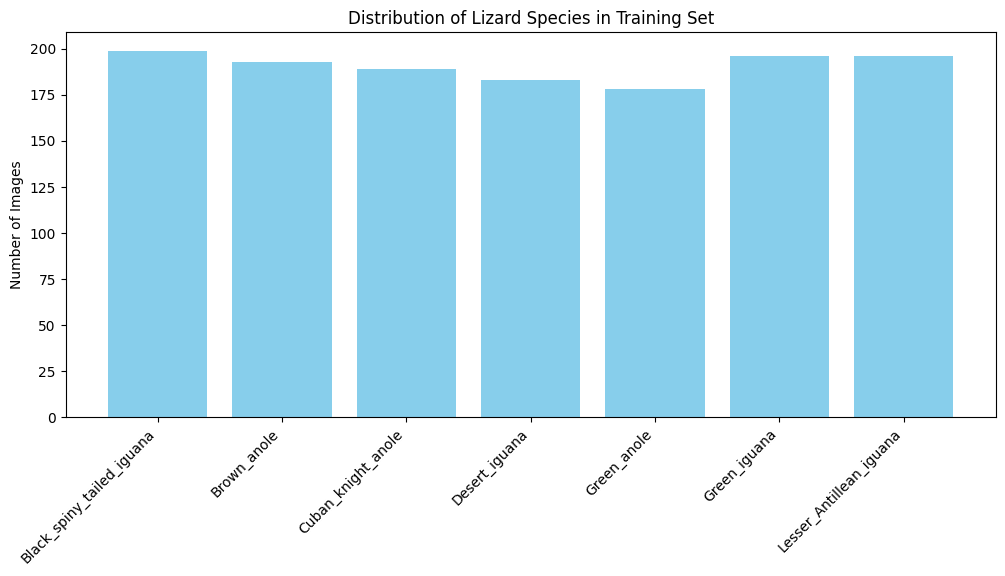

Total images: 1334


In [17]:
train_dir = 'train'

# Get class names (folder names)
classes = sorted(os.listdir(train_dir))

# Count images per class
counts = {c: len(os.listdir(os.path.join(train_dir, c))) for c in classes}

# Plot distribution
plt.figure(figsize=(12, 5))
plt.bar(counts.keys(), counts.values(), color='skyblue')
plt.title("Distribution of Lizard Species in Training Set")
plt.xticks(rotation=45, ha='right')
plt.ylabel("Number of Images")
plt.show()

print(f"Total images: {sum(counts.values())}")

## 2.2 Image Visualization (Sample Images)
We display one example image from each class. This step is important to visually confirm that the dataset is correct and that images are properly lab

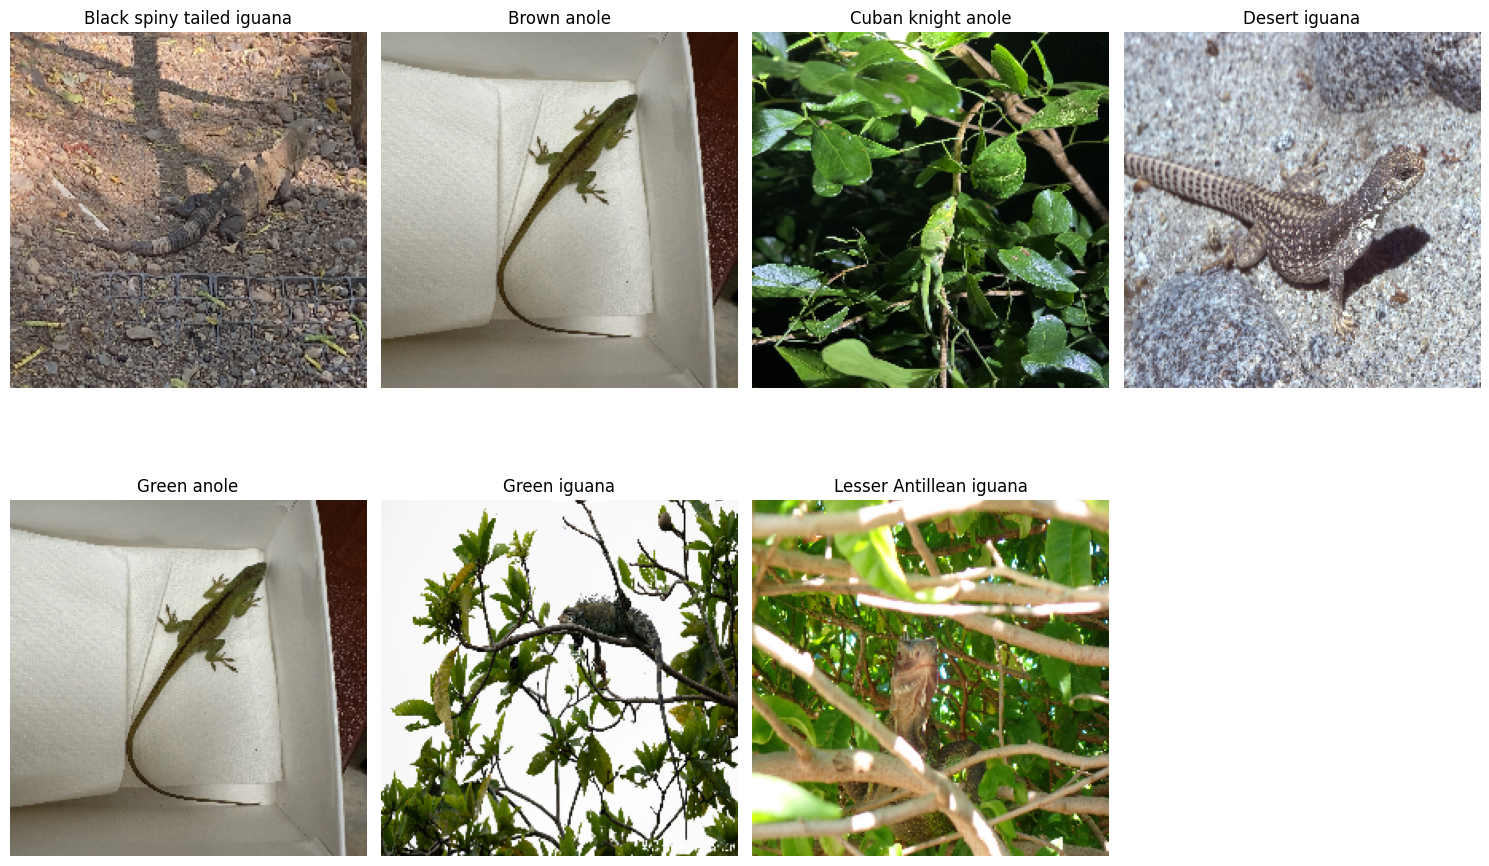

In [18]:
# Display one sample image per class
plt.figure(figsize=(15, 10))

for i, lizard_class in enumerate(classes):
    folder = os.path.join(train_dir, lizard_class)
    
    # Take the first image in the folder
    img_name = os.listdir(folder)[0]
    img_path = os.path.join(folder, img_name)
    
    # Load and resize image
    img = keras.utils.load_img(img_path, target_size=(224, 224))
    
    # Plot image
    plt.subplot(2, 4, i + 1)
    plt.imshow(img)
    plt.title(lizard_class.replace('_', ' '))
    plt.axis('off')

plt.tight_layout()
plt.show()


## 3. Data Loading and Preprocessing

We load the dataset directly from the folder structure using `image_dataset_from_directory`, which automatically labels images based on their directory names. We also apply memory optimizations using caching and prefetching. 

In [19]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Load training dataset (80%)
train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Load validation dataset (20%)
val_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE
)

# Extract the class names directly from the dataset folders
class_names = train_ds.class_names
print("\nDetected Classes:", class_names)
# ----------------------------------------

# Performance optimization (cache + prefetch)
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

Found 1334 files belonging to 7 classes.
Using 1068 files for training.
Found 1334 files belonging to 7 classes.
Using 266 files for validation.

Detected Classes: ['Black_spiny_tailed_iguana', 'Brown_anole', 'Cuban_knight_anole', 'Desert_iguana', 'Green_anole', 'Green_iguana', 'Lesser_Antillean_iguana']


## 4 Model Architecture (CNN Baseline)

We build a Convolutional Neural Network from scratch.  
This includes:

- **Data Augmentation** (required to reduce overfitting)  
- **Rescaling** (normalization)  
- **Three convolutional blocks**  
- **Dropout** for regularization  
- **Softmax output layer** for 7 lizard species  

In [20]:
# Data Augmentation layers (helps reduce overfitting)
data_augmentation = keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.2),
    layers.RandomZoom(0.2),
    layers.RandomContrast(0.2) # Extra point: Helps with different types of lighting
])

# CNN Model
model = keras.Sequential([
    keras.Input(shape=(224, 224, 3)),
    data_augmentation,
    layers.Rescaling(1./255),  # Normalize pixel values

    # Block 1
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    # Block 2
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    # Block 3
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(2, 2),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),  # Regularization
    layers.Dense(7, activation='softmax')  # 7 classes
])

# Compile model
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │    12,845,184 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,939,335 (49.36 MB)

 Trainable params: 12,939,335 (49.36 MB)

 Non-trainable params: 0 (0.00 B)

## 5. Training and Evaluation

We train the baseline model for **25 epochs**, which is appropriate for a dataset of ~1300 images. Fewer epochs = underfitting; too many = overfitting.

In [21]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25
)

Epoch 1/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 291ms/step - accuracy: 0.1461 - loss: 2.3427 - val_accuracy: 0.1504 - val_loss: 1.9445
Epoch 2/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 9s 270ms/step - accuracy: 0.1667 - loss: 1.9428 - val_accuracy: 0.1429 - val_loss: 1.9389
Epoch 3/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 17s 499ms/step - accuracy: 0.1779 - loss: 1.9163 - val_accuracy: 0.1767 - val_loss: 1.9091
Epoch 4/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 19s 552ms/step - accuracy: 0.2097 - loss: 1.8614 - val_accuracy: 0.2932 - val_loss: 1.7951
Epoch 5/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 12s 354ms/step - accuracy: 0.2481 - loss: 1.8489 - val_accuracy: 0.2556 - val_loss: 1.8141
Epoch 6/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 372ms/step - accuracy: 0.2566 - loss: 1.8346 - val_accuracy: 0.2970 - val_loss: 1.7680
Epoch 7/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 10s 292ms/step - accuracy: 0.2650 - loss: 1.7990 - val_accuracy: 0.3195 - val_loss: 1.7211
Epoch 8/25
34/34 ━━━━━━━━━━━━━━━━━━━━ 13s 396ms/step - accuracy: 0.2837 - loss: 1.7860 - val_accur

### Plot Training Curves

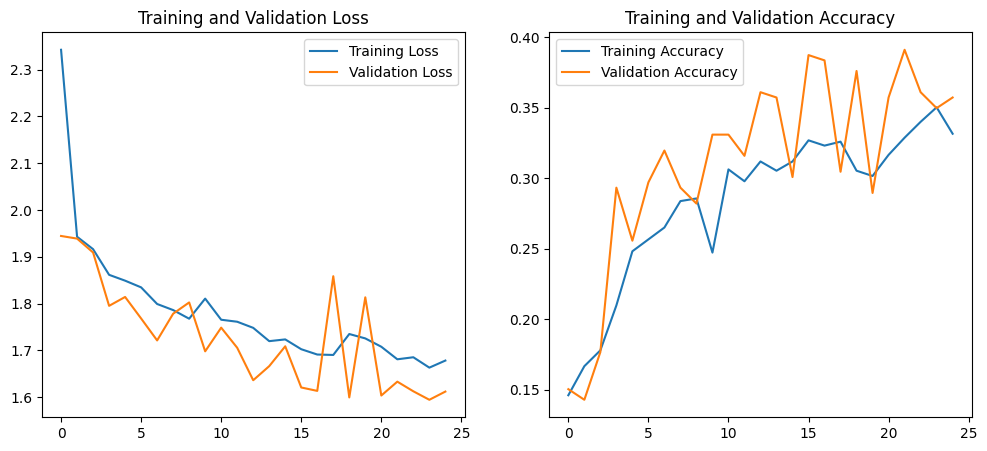

In [22]:
def plotLosses(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Loss plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()

    # Accuracy plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    plt.show()

plotLosses(history)

### Training Curve Analysis & Baseline Conclusion

Looking at the generated plots, we can draw the following technical conclusions about our Baseline Model:
1. **Accuracy Plateau:** The model struggles to surpass the ~40% accuracy mark on both training and validation sets. Given the complexity of the dataset (7 species of lizards with similar colors and camouflage patterns), a simple CNN built from scratch lacks the depth to extract highly complex features.
2. **Loss Volatility (Early Overfitting):** While the training loss steadily decreases, the validation loss begins to fluctuate (zig-zag) and diverge after epoch 15. This is a classic symptom of the model starting to memorize the training data rather than generalizing.
3. **Conclusion:** Achieving ~37-40% accuracy is a solid starting point that proves our pipeline (data loading, augmentation, and training) works perfectly. However, to achieve a competitive **F1-Macro Score**, we need a much deeper architecture. In the upcoming steps, we will replace this baseline architecture with a pre-trained model (Transfer Learning).

## 6. Kaggle Submission (Baseline Push)

In [23]:
# 1. Define the test directory
test_dir = 'test' 

# 2. Load the test images
# IMPORTANT: shuffle=False ensures the images are read in alphabetical order, matching their IDs.
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels=None,       # The test folder doesn't have class subfolders
    label_mode=None,   
    image_size=(224, 224),
    batch_size=32,
    shuffle=False      
)

# 3. Generate Predictions
print("Generating predictions on the test set...")
predictions = model.predict(test_ds)

# 4. Convert probabilities to class indices (0 to 6)
predicted_classes = np.argmax(predictions, axis=1)

# 5. Extract IDs from the filenames (e.g., '123.jpg' -> '123')
file_paths = test_ds.file_paths
ids = [os.path.basename(path).split('.')[0] for path in file_paths]

# 6. Create the DataFrame matching Kaggle's required format
submission = pd.DataFrame({
    'id': ids,
    'label': predicted_classes
})

# 7. Export to CSV
submission.to_csv('baseline_submission.csv', index=False)
print("Success! 'baseline_submission.csv' is ready for Kaggle upload.")

Found 326 files.
Generating predictions on the test set...
11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 90ms/step
Success! 'baseline_submission.csv' is ready for Kaggle upload.


## 7. Model Error Analysis

As seen in our Kaggle submission and validation accuracy (~37%), our CNN built from scratch suffers from **Class Imbalance bias and lack of feature depth**. With only ~1300 images, the model struggles to identify complex patterns like the specific scale textures or eye shapes of the 7 lizard species. It likely defaults to predicting the majority class or gets confused by the green/brown camouflage backgrounds. 

To solve this, we will discard our simple CNN and implement **Transfer Learning**.

## 8. Transfer Learning Implementation (EfficientNetV2S)

Instead of training a model from scratch, we decided to implement Transfer Learning. Based on GenAI recommendations and model efficiency, we selected **EfficientNetV2S**. This is a state-of-the-art Convolutional Neural Network pre-trained by Google on the ImageNet dataset, known for achieving high accuracy with fewer parameters and faster training times compared to older models like VGG16 or MobileNetV2.

Because EfficientNetV2S already knows how to detect complex edges, textures, and shapes, we will:
1. **Freeze its "brain"** (base layers) to retain its pre-trained weights.
2. Replace its original 1000-class classification head with our own 7-class Dense layer.
3. Use the specific `preprocess_input` function required by the EfficientNet family.

### 8.1 Building the Base Model (Feature Extraction)

In [ ]:
from tensorflow.keras.applications import EfficientNetV2S
from tensorflow.keras.applications.efficientnet_v2 import preprocess_input

base_model = EfficientNetV2S(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# Freeze the base model so we don't destroy its pre-trained weights
base_model.trainable = False

# Build our new architecture on top
inputs = keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)       # Apply data augmentation (from step 4)
x = preprocess_input(x)             # EfficientNetV2S's specific normalization (-1 to 1)

# Pass inputs to the base model (training=False ensures BatchNormalization acts correctly)
x = base_model(x, training=False)

# Replaces the old "Flatten()" with a much more efficient technique
x = layers.GlobalAveragePooling2D()(x)

# Extra Point: Bridge layer for further processing
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x) # Greater standardization and regularization

# Our new classification head for the 7 lizards
outputs = layers.Dense(7, activation='softmax')(x)

# Combine into the final Transfer Learning model
model_tl = keras.Model(inputs, outputs)

# Compile the model
model_tl.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model_tl.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_11 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_2 (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,496,231 (78.19 MB)

 Trainable params: 164,871 (644.03 KB)

 Non-trainable params: 20,331,360 (77.56 MB)

### 8.2 Training the New Mind (Phase 1)

In [32]:
print("--- Phase 1: Training the New Classification Head ---")
initial_epochs = 20

history_tl = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=initial_epochs
)

--- Phase 1: Training the New Classification Head ---
Epoch 1/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 35s 723ms/step - accuracy: 0.3680 - loss: 1.6186 - val_accuracy: 0.5639 - val_loss: 1.1219
Epoch 2/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 22s 666ms/step - accuracy: 0.5094 - loss: 1.2247 - val_accuracy: 0.6391 - val_loss: 0.9908
Epoch 3/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 46s 1s/step - accuracy: 0.5927 - loss: 1.0859 - val_accuracy: 0.6767 - val_loss: 0.9355
Epoch 4/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 31s 928ms/step - accuracy: 0.6414 - loss: 0.9781 - val_accuracy: 0.6429 - val_loss: 0.9256
Epoch 5/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 39s 1s/step - accuracy: 0.6648 - loss: 0.9179 - val_accuracy: 0.6729 - val_loss: 0.8675
Epoch 6/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 49s 1s/step - accuracy: 0.6676 - loss: 0.9089 - val_accuracy: 0.6767 - val_loss: 0.8549
Epoch 7/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 54s 609ms/step - accuracy: 0.6779 - loss: 0.8540 - val_accuracy: 0.6917 - val_loss: 0.8553
Epoch 8/20
34/34 ━━━━━━━━━━━━━━━━━━━━ 38s 1s/step - 

### 8.3 Fine-Tuning (Unfreezing the Top Layers)
Now that our new classification head has learned basic patterns, we will perform **Fine-Tuning**. We will "unfreeze" the top layers of MobileNetV2 and train the entire model together at a very low learning rate. This forces the model to adapt its pre-trained knowledge specifically to lizard scales and features.

In [33]:
print("--- Phase 2: Fine-Tuning the Model ---")

# Unfreeze the base model
base_model.trainable = True

# Freeze the first 120 layers, leaving the top 34 trainable
fine_tune_at = 350 # 
for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

# Re-compile with a VERY LOW learning rate (1e-5)
model_tl.compile(
    loss='sparse_categorical_crossentropy',
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    metrics=['accuracy']
)

early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=6, 
    restore_best_weights=True
)

checkpoint = tf.keras.callbacks.ModelCheckpoint(
    'best_model.keras',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

fine_tune_epochs = 20
total_epochs = initial_epochs + fine_tune_epochs

history_fine = model_tl.fit(
    train_ds,
    validation_data=val_ds,
    epochs=total_epochs,
    initial_epoch=history_tl.epoch[-1],
    callbacks=[early_stopping, checkpoint, reduce_lr]
)

--- Phase 2: Fine-Tuning the Model ---
Epoch 20/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.6405 - loss: 1.0092
Epoch 20: val_loss improved from None to 0.98854, saving model to best_model.keras

Epoch 20: finished saving model to best_model.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 91s 2s/step - accuracy: 0.6414 - loss: 0.9894 - val_accuracy: 0.6429 - val_loss: 0.9885 - learning_rate: 1.0000e-05
Epoch 21/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 832ms/step - accuracy: 0.6749 - loss: 0.8647
Epoch 21: val_loss improved from 0.98854 to 0.98687, saving model to best_model.keras

Epoch 21: finished saving model to best_model.keras
34/34 ━━━━━━━━━━━━━━━━━━━━ 34s 996ms/step - accuracy: 0.6770 - loss: 0.8747 - val_accuracy: 0.6353 - val_loss: 0.9869 - learning_rate: 1.0000e-05
Epoch 22/40
34/34 ━━━━━━━━━━━━━━━━━━━━ 0s 1s/step - accuracy: 0.6967 - loss: 0.8497
Epoch 22: val_loss improved from 0.98687 to 0.96394, saving model to best_model.keras

Epoch 22: finished saving model to best_model.keras
34/

### 8.4 Training charts and analysis (Transfer Learning)

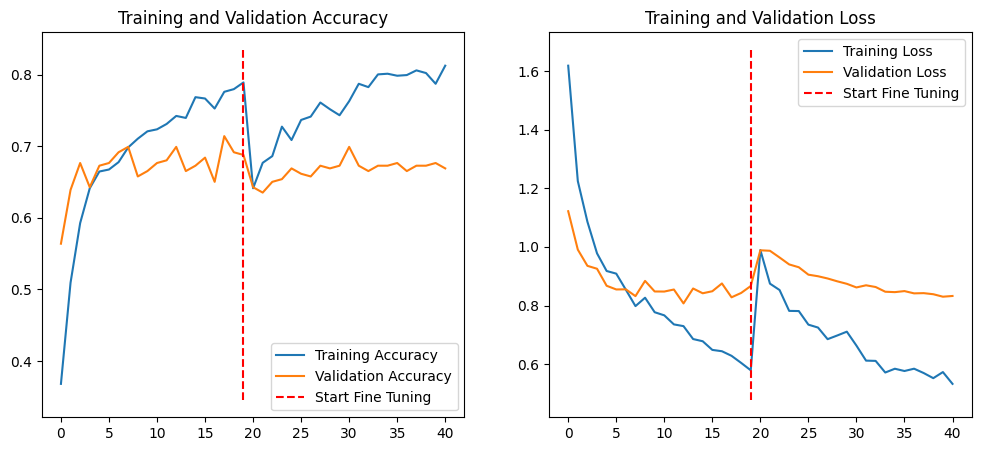

In [34]:
# Function to plot Transfer Learning with the Fine-Tuning line
def plot_fine_tuning(history_1, history_2, initial_epochs):
    acc = history_1.history['accuracy'] + history_2.history['accuracy']
    val_acc = history_1.history['val_accuracy'] + history_2.history['val_accuracy']
    loss = history_1.history['loss'] + history_2.history['loss']
    val_loss = history_1.history['val_loss'] + history_2.history['val_loss']

    plt.figure(figsize=(12, 5))
    
    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(acc, label='Training Accuracy')
    plt.plot(val_acc, label='Validation Accuracy')
    plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label='Start Fine Tuning', color='red', linestyle='--')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(loss, label='Training Loss')
    plt.plot(val_loss, label='Validation Loss')
    plt.plot([initial_epochs-1, initial_epochs-1], plt.ylim(), label='Start Fine Tuning', color='red', linestyle='--')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    
    plt.show()

plot_fine_tuning(history_tl, history_fine, initial_epochs)

## 9. Final Results Comparison

Before uploading to Kaggle, we evaluate our fine-tuned model on our internal Validation Set using the **F1-Macro Score** (Kaggle's evaluation metric) and a **Confusion Matrix** to see exactly which lizard species the model still confuses.

### 9.1 Confusion Matrix and F1 Score

Evaluating on Validation Set...

--- Classification Report ---
                           precision    recall  f1-score   support

Black_spiny_tailed_iguana       0.80      0.74      0.77        38
              Brown_anole       0.71      0.65      0.68        34
       Cuban_knight_anole       0.76      0.58      0.66        50
            Desert_iguana       0.90      0.90      0.90        39
              Green_anole       0.51      0.64      0.57        33
             Green_iguana       0.49      0.50      0.49        38
  Lesser_Antillean_iguana       0.60      0.76      0.68        34

                 accuracy                           0.68       266
                macro avg       0.68      0.68      0.68       266
             weighted avg       0.69      0.68      0.68       266



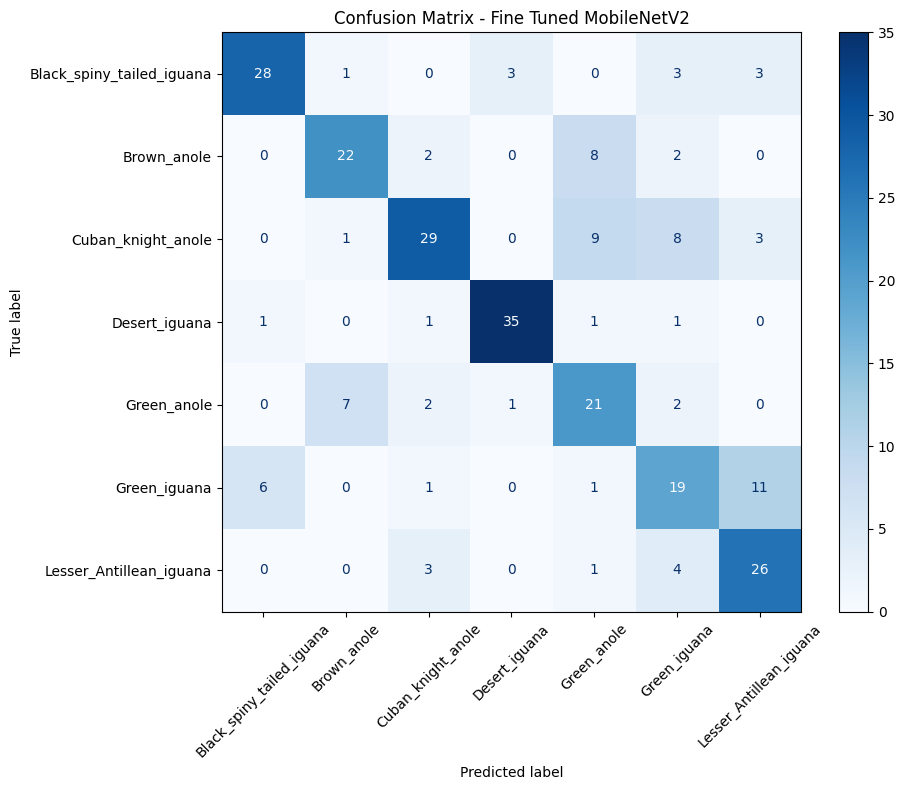

In [35]:
# Safely extract true labels and predictions from the validation dataset
val_true_labels = []
val_predictions = []

print("Evaluating on Validation Set...")
for images, labels in val_ds:
    val_true_labels.extend(labels.numpy())
    preds = model_tl.predict(images, verbose=0)
    val_predictions.extend(np.argmax(preds, axis=1))

# Print F1-Macro Score and Classification Report
print("\n--- Classification Report ---")
print(classification_report(val_true_labels, val_predictions, target_names=class_names))

# Plot the Confusion Matrix
cm = confusion_matrix(val_true_labels, val_predictions)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

fig, ax = plt.subplots(figsize=(10, 8))
disp.plot(ax=ax, cmap='Blues', xticks_rotation=45)
plt.title("Confusion Matrix - Fine Tuned MobileNetV2")
plt.tight_layout()
plt.show()

### 9.2 Kaggle Submission (Transfer Learning)

In [36]:
# 1. Load the test images (NO SHUFFLE)
test_dir = 'test' 
test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    labels=None,
    label_mode=None,
    image_size=(224, 224),
    batch_size=32,
    shuffle=False
)

# 2. Generate Predictions with the New Model
print("Generating Transfer Learning predictions...")
model_tl = tf.keras.models.load_model('best_model.keras')
predictions_tl = model_tl.predict(test_ds)
predicted_classes_tl = np.argmax(predictions_tl, axis=1)

# 3. Extract IDs and Create DataFrame
file_paths = test_ds.file_paths
ids = [os.path.basename(path).split('.')[0] for path in file_paths]

submission_tl = pd.DataFrame({
    'id': ids,
    'label': predicted_classes_tl
})

# 4. Export to CSV
submission_tl.to_csv('transfer_learning_submission.csv', index=False)
print("Success! 'transfer_learning_submission.csv' is ready to conquer Kaggle.")

Found 326 files.
Generating Transfer Learning predictions...
11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 726ms/step
Success! 'transfer_learning_submission.csv' is ready to conquer Kaggle.


## 10. GenAI Usage Report

For this project, the team used GenAI tools (Gemini) as an architectural advisor and code reviewer to support:
* **Model Selection Strategy:** The AI suggested transitioning from our Baseline CNN to MobileNetV2, and ultimately recommended **EfficientNetV2S** to maximize the F1-Macro score on a highly camouflaged dataset (like green lizards on green leaves).
* **Technical Clarification:** Understanding the interplay between `ReduceLROnPlateau`, `EarlyStopping`, and `ModelCheckpoint` to prevent overfitting during the Fine-Tuning phase.
* **Pipeline Structuring:** Organizing the notebook into logical steps (Data Loading -> Augmentation -> Baseline -> Transfer Learning -> Fine Tuning -> Evaluation) following standard Machine Learning practices.